In [172]:
import sys 
sys.path.append("../../src/")
import TFIM_operators_from_states as operators
import numerical_quenches as nq
from project_imports import *

In [ ]:
def op(n):
    return ["I", f"x{n}", f"z{n}"]

def distribute(L1, L2):
    return [f"{u}{v}" for u in L1 for v in L2]

def distribute_list(List):
    L1 = List[0]
    for L2 in List[1:]:
        L1 = distribute(L1,L2)
    return L1
x=distribute(distribute(op(1), op(2)),op(3))

def reduce_string(str):
    str= str.replace("I","")
    if str.count("x")%2==1:
        return ""
    
    return str
def translational_invariance(string):
    string = list(string)
    x0 = int(string[1])
    for i in range(1,len(string),2):
        string[i] = str(int(string[i])-x0)
    return "".join(string)

import re

def translational_invariance(string):
    parts = re.findall(r'([A-Za-z]+)(\d+)', string)

    if not parts:
        return string

    x0 = int(parts[0][1])

    shifted = [(op, str(int(idx) - x0)) for op, idx in parts]

    return "".join(op + idx for op, idx in shifted)

def filter_terms(list):
    #Removes any Identities and odd parity x terms
    new_list = [reduce_string(item) for item in list if reduce_string(item) != ""]
    #Translational_Invariance
    new_list = [translational_invariance(item) for item in new_list]
    
    return new_list

from collections import Counter
def degeneracy_counter(terms):
    items =list(Counter(terms).keys())
    degeneracies =list(Counter(terms).values())
    return items,degeneracies


###############################
#Majorana Fermions
###############################
def Prepare_Term_For_Majorana_Strings(term):
    term = list(term)
    operators=term[::2]
    indices = term[1::2]
    z_indices=[]
    x_indices=[]
    for operator, index in zip(operators,indices):
        if operator=="z":
            z_indices.append(int(index))
        elif operator=="x":
            x_indices.append(int(index))
    return z_indices, x_indices

from TFIM_operators_from_states import Create_Majorana_Strings_Z, Create_Majorana_Strings_X
def Majorana_Strings_X(indices):
    pairs = [indices[i:i+2] for i in range(0, len(indices), 2)]
    Majorana_String = Create_Majorana_Strings_X(pairs)
    return Majorana_String

def Majorana_String_Filter(String):
    counts = Counter(String)
    new_list = [x for x, c in counts.items() if c == 1]
    return new_list

def Create_Majorana_Strings_XZ(term):
    z_indices, x_indices = Prepare_Term_For_Majorana_Strings(term)
   # print(x_indices)
    x_string = Majorana_Strings_X(x_indices)
    z_string = Create_Majorana_Strings_Z(z_indices)
    majorana_string = Majorana_String_Filter(x_string+z_string)

    return majorana_string

def Generic_Correlation(term,state):
    parity = term.count("x")
    sign = 1#(-1) ** (parity // 2)
    majorana_string = Create_Majorana_Strings_XZ(term)
   # print(majorana_string)
    M=operators.Majorana_Covariance(majorana_string,state)
   # print("M was successful")
    return sign*operators.Pfaffian(M)


#######
#Full Projector
#######

def Unit_Vector_Coefficient(term,nhat):
    xs = term.count("x")
    zs = term.count("z")
    return nhat[0]**xs*nhat[1]**zs

from joblib import Parallel, delayed

def compute_term(unique_term, degen,nhat,state):
    coefficient = Unit_Vector_Coefficient(unique_term, nhat)
    O = Generic_Correlation(unique_term, state)
    return (O * degen) * coefficient


#
#expectation_value = sum(results)
def P_generic(N,nhat,state):
    sites=  np.arange(0,N)
    operators = distribute_list([op(site) for site in sites])
    operators = filter_terms(operators)
    uniques,degeneracies = degeneracy_counter(operators)
    #expectation_value = 1
    # for unique_term,degen in zip(uniques,degeneracies):
    #     coefficient = Unit_Vector_Coefficient(unique_term,nhat)
    #     O = Generic_Correlation(unique_term,state)
    #     expectation_value += (O*degen)*coefficient

    results = Parallel(n_jobs=-1)(
    delayed(compute_term)(unique_term, degen,nhat,state)
    for unique_term, degen in zip(uniques, degeneracies))
    expectation_value = np.sum(results)+1
    return expectation_value/2**(N)




    

In [315]:
operators.Majorana_Covariance([('B',0),('A',0)],psi0)

array([[ 0.        +0.j,  0.63664595-0.j],
       [-0.63664595+0.j,  0.        +0.j]])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


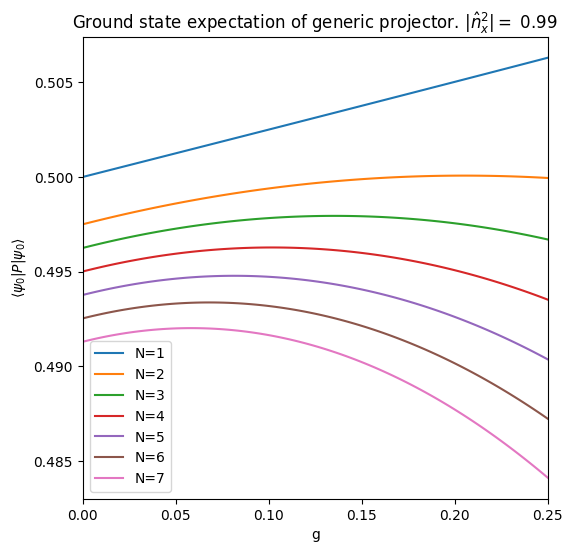

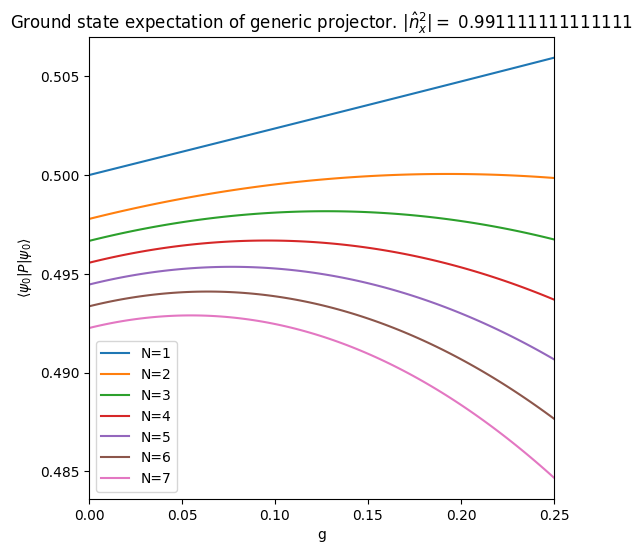

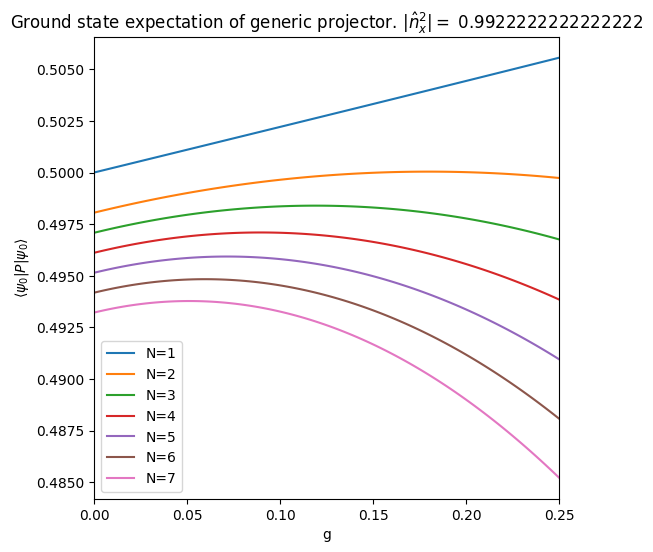

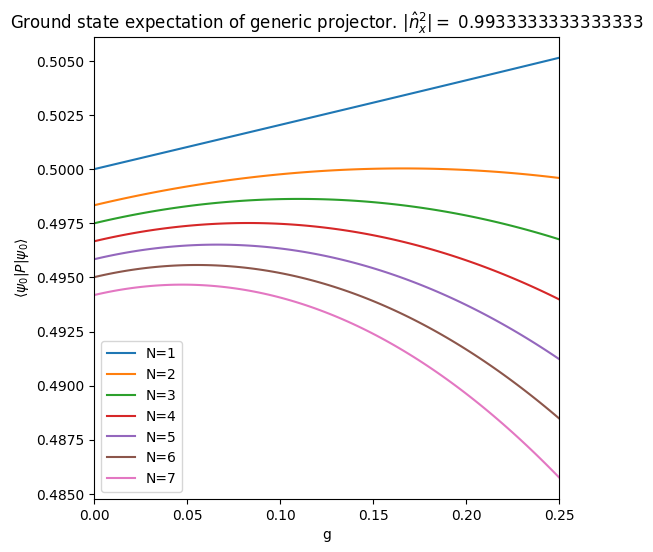

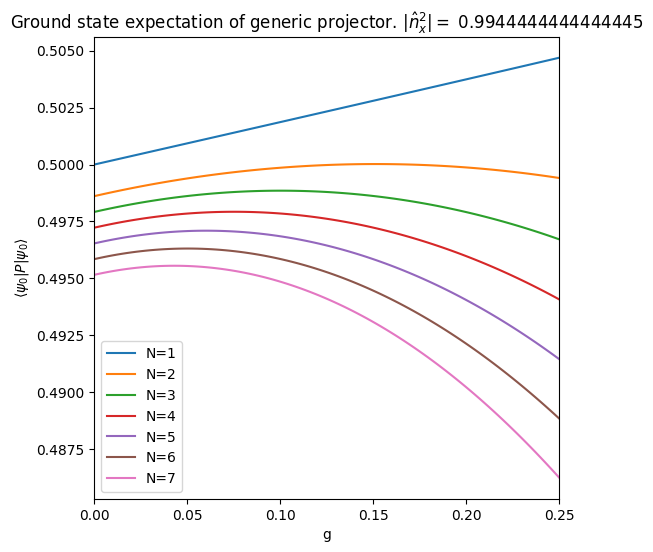

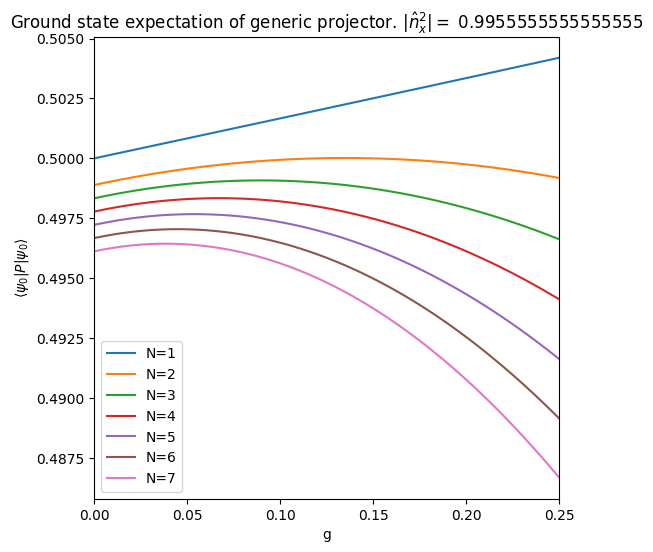

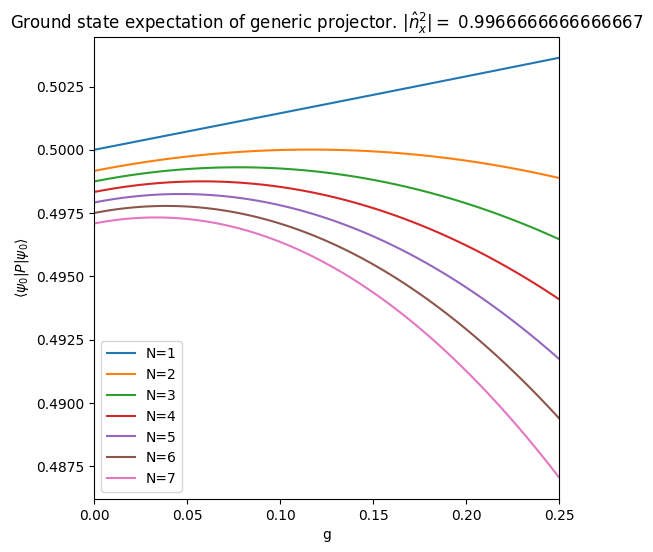

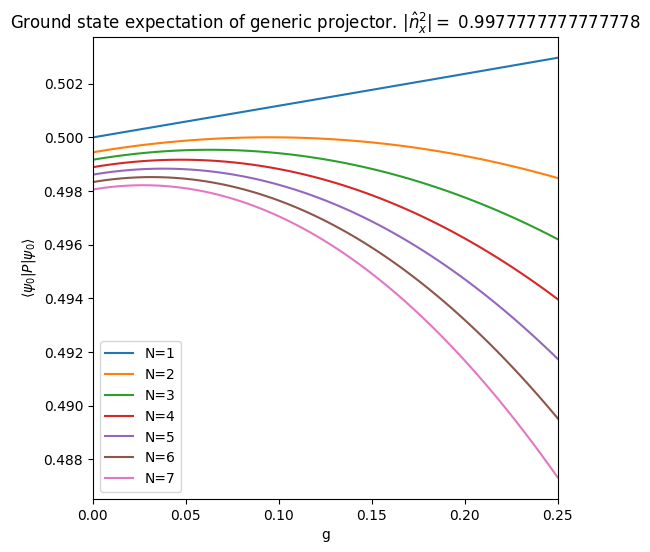

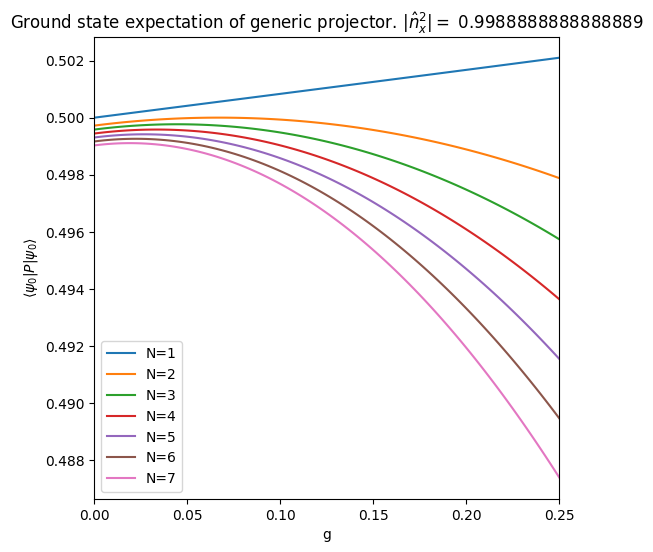

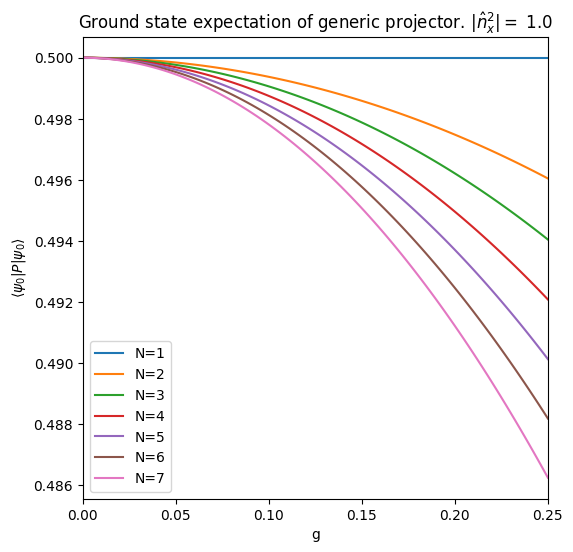

In [325]:
Ns = np.arange(1,8)
p = .99
ps = np.linspace(0.99,1,10)

for p in ps:
    plt.figure(figsize=(6,6))
    for N in Ns:
        nhat= (sqrt(p),sqrt(1-p))
        data=[]
        g= np.linspace(0,.25,100)
        for gi in g:
            psi0 = nq.groundstate(gi,100)

            data.append(P_generic(N,nhat,psi0))
        plot(g,data,label=f"N={N}")
        xlabel("g")
        legend()
        xlim(g[0],g[-1])
        ylabel(r"$\langle \psi_0|P|\psi_0\rangle$")

        title(rf"Ground state expectation of generic projector. $|\hat n_x^2| =$ {p}")
    show()

In [341]:
L = 200
g0=5
tau = .01
args = (tau,tau)
t_eval_quench = np.linspace(-(5-1)*tau,tau,100)
t_eval_free = np.linspace(0,1*pi/4,100)
states = nq.states(L,t_eval_quench,nq.g_linear_hold,args)
states2= nq.states(L,t_eval_free,nq.g_linear_hold,args,states[-1])

g0=5.0
g0=1.0


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


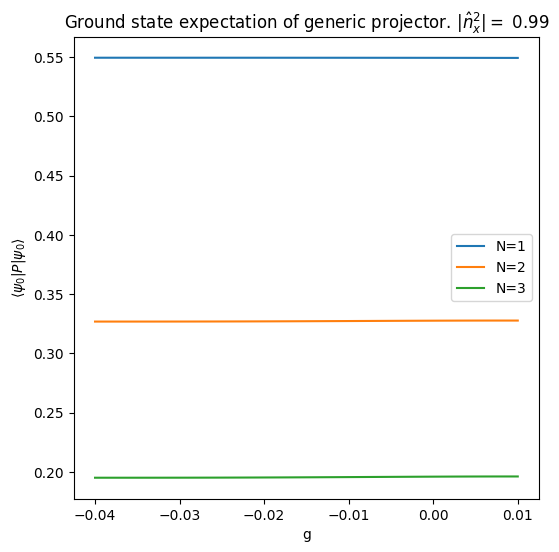

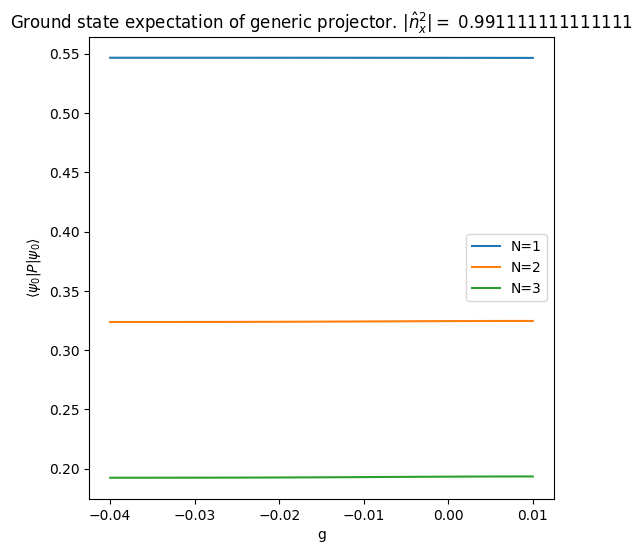

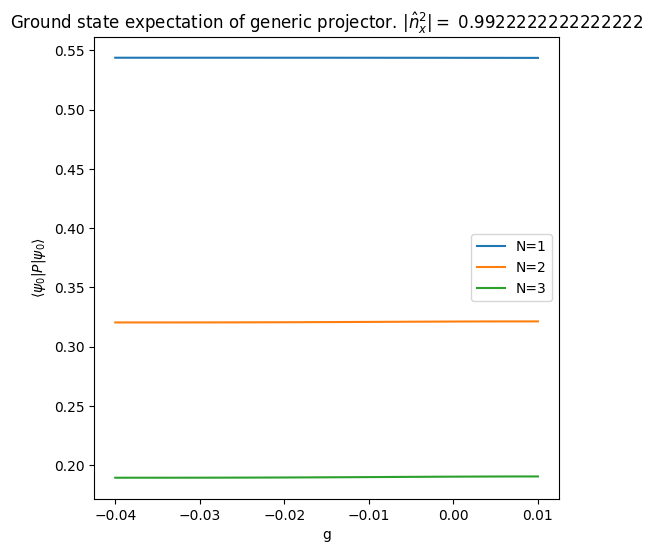

KeyboardInterrupt: 

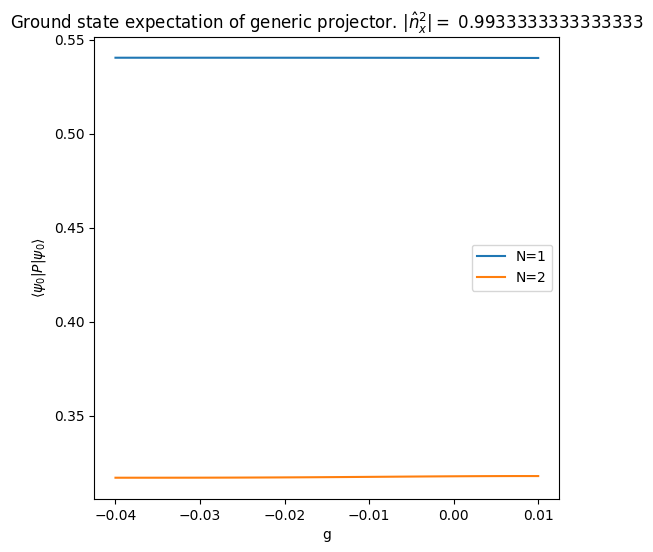

In [335]:
Ns = np.arange(1,4)
p = .99
ps = np.linspace(0.99,1,10)

for p in ps:
    plt.figure(figsize=(6,6))
    for N in Ns:
        nhat= (sqrt(p),sqrt(1-p))
        data=[]
        g= np.linspace(0,.25,100)
        for s in states:


            data.append(P_generic(N,nhat,s))
        plot(t_eval_quench,data,label=f"N={N}")
        xlabel("g")
        legend()
        #xlim(g[0],g[-1])
        ylabel(r"$\langle \psi_0|P|\psi_0\rangle$")

        title(rf"Ground state expectation of generic projector. $|\hat n_x^2| =$ {p}")
    show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


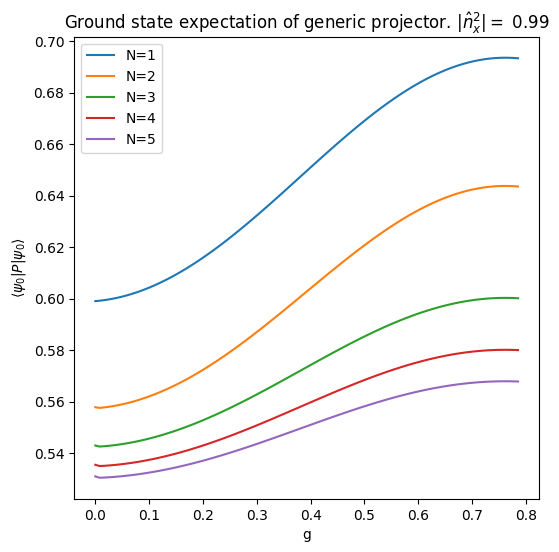

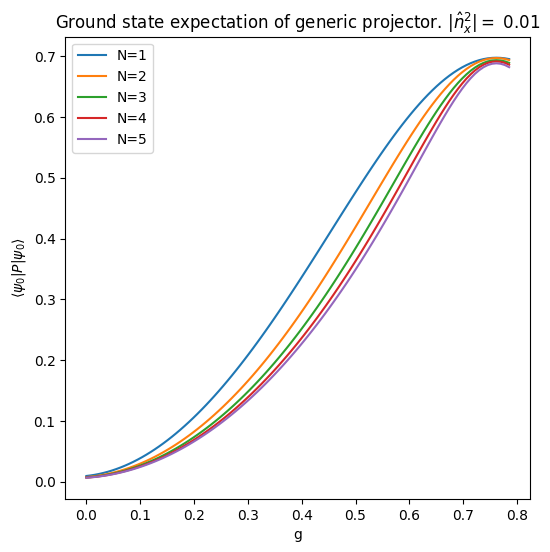

In [345]:
Ns = [1,2,3,4,5]
p = .99
ps = [.99,.01]

for p in ps:
    plt.figure(figsize=(6,6))
    for N in Ns:
        nhat= (sqrt(p),sqrt(1-p))
        data=[]
        g= np.linspace(0,.25,100)
        for s in states2:


            data.append(P_generic(N,nhat,s))
        plot(t_eval_free,-log(data)/N,label=f"N={N}")
        xlabel("g")
        legend()
        #xlim(g[0],g[-1])
        ylabel(r"$\langle \psi_0|P|\psi_0\rangle$")

        title(rf"Ground state expectation of generic projector. $|\hat n_x^2| =$ {p}")
    show()

In [398]:
def filter_linear_z(terms,degeneracies):
    filtered_terms =[]
    filtered_degeneracy=[]
    for term,degen in zip(terms,degeneracies):
        if term.count("z")== 1:
            filtered_terms.append(term)
            filtered_degeneracy.append(degen)

    return filtered_terms, filtered_degeneracy
def O(N,state):
    sites=  np.arange(0,N)
    operators = distribute_list([op(site) for site in sites])
    operators = filter_terms(operators)
    uniques,degeneracies = degeneracy_counter(operators)
    uniques,degeneracies = filter_linear_z(uniques,degeneracies)

    results = [Generic_Correlation(term,state)*degen for term,degen in zip(uniques,degeneracies)]
    expectation_value = np.sum(results)
    return expectation_value/2**(N)


def compute_term(unique_term, degen,nhat,state):
    coefficient = Unit_Vector_Coefficient(unique_term, nhat)
    O = Generic_Correlation(unique_term, state)
    return (O * degen) * coefficient


In [401]:
O(3,state)

np.float64(0.0)

In [439]:
L = 200
g0=5
tau = 100
args = (tau,tau)
t_eval_quench = np.linspace(-(5-1)*tau,tau,100)
t_eval_free = np.linspace(0,3*tau,1000)
states = nq.states(L,t_eval_quench,nq.g_linear_hold,args)
states2= nq.states(L,t_eval_free,nq.g_linear_hold,args,states[-1])

g0=5.0
g0=1.0


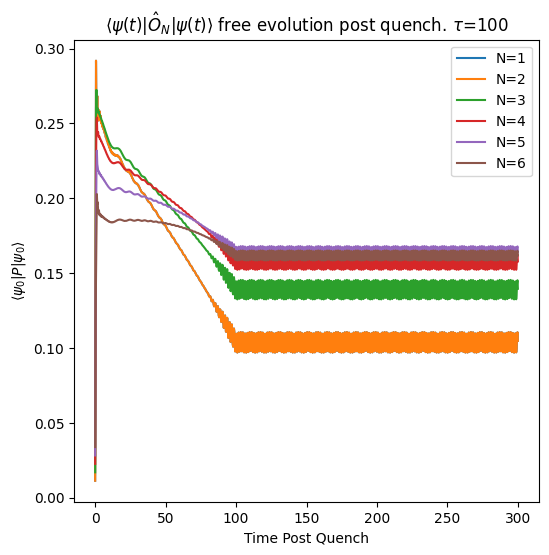

In [441]:
Ns = [1,2,3,4,5,6]
plt.figure(figsize=(6,6))
Projector_data=[]
for N in Ns:
    data=[]
    for s in states2:


        data.append(O(N,s))
    plot(t_eval_free,data,label=f"N={N}")
    xlabel("Time Post Quench")
    legend()
        #xlim(g[0],g[-1])
    ylabel(r"$\langle \psi_0|P|\psi_0\rangle$")

    title(rf"$\langle \psi(t)| \hat O _N | \psi(t) \rangle$ free evolution post quench. $\tau$={tau}")
    Projector_data.append(data)
show()